### Exploration & Data Loading

In [2]:
%pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


Note: you may need to restart the kernel to use updated packages.


In [3]:
df=pd.read_csv("C:\\Users\\Bits solution\\Desktop\\Customer Churn Prediction\\data\\raw\\WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.shape

(7043, 21)

In [4]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [5]:
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


1)based on the .describe(and exploration) we can see that most categorical variables have between 2,3 or 4 categories

2)so for those that have 2 (binary) let's just replace by 0 and 1

3)For those that have 3 or 4 we can do one-hot encoding

### Binary Encoding

In [7]:
# Binary categories columns(2 unique values)
binary_cols=[
    'gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn'
]
# Map Yes/No and Male/Female to 0/1
df[binary_cols]=df[binary_cols].replace({
    'Yes':1,'No':0,
    'Male':1,'Female':0
})

C:\Users\Bits solution\AppData\Local\Temp\ipykernel_6472\332287744.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols]=df[binary_cols].replace({


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [9]:
# Categorical Column with >2 unique values
multi_cat_cols=[
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'
]
df=pd.get_dummies(df,columns=multi_cat_cols,drop_first=True)

In [10]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


### Cleaning

In [11]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [12]:
df=df.drop('customerID',axis=1)

In [13]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)  #convert TRUE/False to 0/1 for all boolean cols

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [15]:
corr_matrix=df.corr(numeric_only=True)
churn_corr=corr_matrix['Churn'].sort_values(ascending=False)

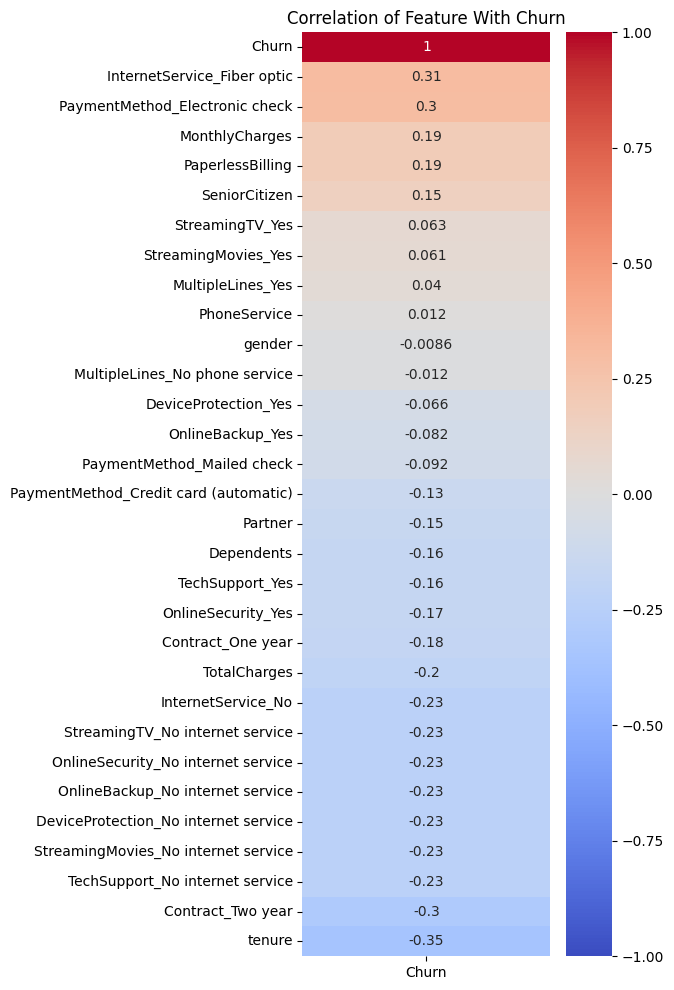

In [16]:
# Compute correlation matrix only for numeric columns
corr_matrix=df.corr(numeric_only=True)

#FocusOn Correlation With Churn
churn_corr=corr_matrix[['Churn']].sort_values(by='Churn',ascending=False)

# Plot Heatmap
plt.figure(figsize=(4,12))
sns.heatmap(churn_corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('Correlation of Feature With Churn')
plt.show()

Negative (lower value --> less likely to churn): a)tenure(-0.35)-> Customers who stay longer are less likely to churn b)Contract_Two year(-0.30)--> Customers on long-term contracts churn much less c) Contract_one year(-0.18)-->Same trend but weaker than two-year contracts
2)Positive(higher value--> more likely to churn): a) InternetService_Fiber optic(+0.31)-->Fiber optic users churn more in this dataset. b)PaymentMethod_Electronic Check(+0.30)-->Customers paying electronically via check churn more.

### Look for Multicolinearity(VIF)

In [17]:
# We need to collapse redundant column before running VIF
df['No_internet_service']=(
    df['OnlineSecurity_No internet service']|
    df['OnlineBackup_No internet service']|
    df['DeviceProtection_No internet service']|
    df['TechSupport_No internet service']|
    df['StreamingTV_No internet service']|
    df['StreamingMovies_No internet service']
).astype(int)

#Drop the original redundant dummies
drop_cols=[col for col in df.columns if 'No internet service' in col]
df=df.drop(columns=drop_cols)

# Handle PhoneSErvice Redundancy
if 'MultipleLines_No phone service' in df.columns:
  df['No_phone_service']=df['MultipleLines_No phone service'].astype(int)
  df=df.drop(columns=['MultipleLines_No phone service'])

In [18]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Prepare data for VIF analysis
X = df.drop(columns=['Churn'])

#Remove rows with missing or infinite values
X=X.replace([np.inf,-np.inf],np.nan)
X=X.dropna()

vif_data=pd.DataFrame()
vif_data['feature']=X.columns
vif_data['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data=vif_data.sort_values(by='VIF',ascending=False)
print(vif_data)

c:\Users\Bits solution\Desktop\Customer Churn Prediction\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

Clearly we can see there is mulicolinearity between features
So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this 3)Or use trees ,splits are based on feature importanxce for reducing impurity-redundant features just compete,but won't cause unstable prediction

### Machine learning

In [19]:
# we have a class imbalance problem
# Given your imbalance (27% churners),class weighting+ threshold tuning is probably enough -no need for aggressive oversame
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In churn prediction , recall(and metrices derived from it ,like F1)is usually the most important --here's why:

Business Context Churn Prediction is asymmetric in cost:
a)False Negative(FN): You Predict a customer will not churn , but they actually leave-->you miss the chnace to intervene and keep them. b)False Positive(FP):you predict a customer will churn ,but they stay-->you might spend some retention resource unnecessary. c)Missing Churners(FN) usually cost more than wrongly targeting a loyal customer.

2.Typical Priority

If retention campaigns are cheap--> priritize recall(catch every possible churner)
If retention campaigns are expensive --> balance precision and recall using F1 score or a precision-recall trade-off 3)If business wants a ranking of churn risk-->use ROC-AOC or PR-AUC to evaluate the model



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import pandas as pd
import time

In [21]:
# Prepare Data
X=df.drop(columns=['Churn'])
y=df['Churn']
#train-test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
THRESHOLD=0.3    # lower than 0.5 to boost recall(see next to choose the right value)

### RandomForest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf=RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)

proba=rf.predict_proba(X_test)[:,1]
y_pred=(proba>=THRESHOLD).astype(int)

print(classification_report(y_test,y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.883     0.771     0.823      1035
           1      0.531     0.717     0.610       374

    accuracy                          0.757      1409
   macro avg      0.707     0.744     0.716      1409
weighted avg      0.789     0.757     0.766      1409



### LightGBM classifier

In [23]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


# Training timer
start_train=time.time()
lgbm.fit(X_train,y_train)
train_time=time.time()-start_train
print(f"Training time:{train_time:.2f}seconds")

#Prediction timer
start_pred=time.time()
proba=lgbm.predict_proba(X_test)[:,1]
y_pred=(proba>=THRESHOLD).astype(int)
pred_time=time.time()-start_pred
print(f"Prediction time:{pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test,y_pred,digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time:0.83seconds
Prediction time:0.0149 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733     0

In [24]:
from sklearn.metrics import precision_score,recall_score,f1_score
proba=lgbm.predict_proba(X_test)[:,1]
print("Threshold tuning for LightGBM")
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25,0.30,0.35,0.40,0.45,0.50]:
  preds=(proba>=thresh).astype(int)
  prec=precision_score(y_test,preds,pos_label=1)
  rec=recall_score(y_test,preds,pos_label=1)
  f1=f1_score(y_test,preds,pos_label=1)
  print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


### Xgboost classifier

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()

xgb=XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)
# Training timer
start_train=time.time()
xgb.fit(X_train,y_train)
train_time=time.time()-start_train
print(f"Training time:{train_time:.2f} seconds")

#Prediction timer
start_pred=time.time()
proba=xgb.predict_proba(X_test)[:,1]

# Classification report
print(classification_report(y_test,y_pred,digits=3))

Training time:0.99 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733     0.748      1409



In [26]:
from sklearn.metrics import precision_score,recall_score,f1_score
proba=xgb.predict_proba(X_test)[:,1]
print("Threshold tuning for XGBoost")
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25,0.30,0.35,0.40,0.45,0.50]:
    preds=(proba>=thresh).astype(int)
    prec=precision_score(y_test,preds,pos_label=1)
    rec=recall_score(y_test,preds,pos_label=1)
    f1=f1_score(y_test,preds,pos_label=1)
    print(f"{thresh:<8.2f}{prec:<8.2f}{rec:<8.2f}{f1:<8.2f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.47    0.84    0.60    
0.30    0.48    0.82    0.61    
0.35    0.50    0.79    0.62    
0.40    0.52    0.77    0.62    
0.45    0.54    0.74    0.62    
0.50    0.55    0.70    0.62    


ML model choise XGBoost
    1)Gives a decent recall(same as LightGBM)
    2) AND faster to train(3x faster)

### Hyperparameter Tuning(Optuna) & Experiment Tracking (MLFlow)

In [27]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba > THRESHOLD).astype(int)

    return recall_score(y_test, y_pred, pos_label=1)

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

c:\Users\Bits solution\Desktop\Customer Churn Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-22 23:14:53,965] A new study created in memory with name: no-name-86218120-4618-47fe-a0bf-da76063438dd
[I 2026-03-22 23:14:54,625] Trial 0 finished with value: 0.8877005347593583 and parameters: {'n_estimators': 486, 'learning_rate': 0.10554306956076584, 'max_depth': 4, 'subsample': 0.5501890802911056, 'colsample_bytree': 0.6465036864409472, 'min_child_weight': 1, 'gamma': 2.156319811918928, 'reg_alpha': 2.370560975300153, 'reg_lambda': 4.92161108268443}. Best is trial 0 with value: 0.8877005347593583.
[I 2026-03-22 23:14:55,480] Trial 1 finished with value: 0.8636363636363636 and parameters: {'n_estimators': 505, 'learning_rate': 0.0499700524078487, 'max_depth': 7, 'subsample': 0.6490529553685

Best Params: {'n_estimators': 406, 'learning_rate': 0.01200121558773766, 'max_depth': 3, 'subsample': 0.9254417769952343, 'colsample_bytree': 0.6195607483080326, 'min_child_weight': 4, 'gamma': 1.1195250330575042, 'reg_alpha': 0.29801494542968043, 'reg_lambda': 4.010940391037469}
Best Recall: 0.93048128342246


In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params=study.best_params
best_params.update(
    {
    "random_state":42,
    "n_jobs":-1,
    "scale_pos_weight":scale_pos_weight,
    "eval_metric":"logloss"
    }
)

# Create model from best params
xgb=XGBClassifier(**best_params)

# Training timer
start_train=time.time()
xgb.fit(X_train,y_train)
train_time=time.time()-start_train
print(f"Training time:{train_time:.2f} seconds")

# Prediction timer
start_pred=time.time()
proba=xgb.predict_proba(X_test)[:,1]
y_pred=(proba>=THRESHOLD).astype(int) # Recalculate y_pred with the new model's probabilities
pred_time=time.time()-start_pred
print(f"Prediction time:{pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test,y_pred,digits=3))


Training time:0.50 seconds
Prediction time:0.0125 seconds
              precision    recall  f1-score   support

           0      0.956     0.549     0.697      1035
           1      0.427     0.930     0.585       374

    accuracy                          0.650      1409
   macro avg      0.692     0.740     0.641      1409
weighted avg      0.816     0.650     0.668      1409

